# Bai Thuc Hanh So 4: So Sanh Anh Bang Wavelet Transform

**Muc tieu:** Xay dung he thong so sanh su tuong dong cua cac hinh anh su dung bien doi Wavelet (DWT) trong Python.

**Phuong phap:** Wavelet Hash (wHash) - bien doi anh thanh chuoi bit nhi phan thong qua DWT, sau do so sanh bang khoang cach Hamming.

---

**Cau truc notebook:**
1. Cai dat thu vien & cau hinh
2. Tien xu ly du lieu
3. Xay dung Wavelet Hash
4. So sanh anh
5. Danh gia mo hinh
6. Visualization
7. Bai nang cao - so sanh cac wavelet

## Phan 1: Import & Cau Hinh

In [37]:
# ============================================================
# IMPORT THU VIEN
# ============================================================
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pywt

from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)

warnings.filterwarnings("ignore")

# ============================================================
# CAU HINH DUONG DAN
# ============================================================
BASE_DIR  = "data/DWT"
CSV_PATH  = "data/DWT/pairs.csv"
IMAGE_DIR = "."  # De trong vi pairs.csv da co duong dan tuong doi

# Kiem tra neu dang chay tu thu muc notebooks thi dieu chinh duong dan
if not os.path.exists(BASE_DIR) and os.path.exists(os.path.join("..", BASE_DIR)):
    BASE_DIR  = os.path.join("..", BASE_DIR)
    CSV_PATH  = os.path.join("..", CSV_PATH)
    IMAGE_DIR = ".."

# ============================================================
# THAM SO TOAN CUC
# ============================================================
RANDOM_SEED   = 42          # de tao lai ket qua
HASH_SIZE     = 8           # kich thuoc hash: HASH_SIZE x HASH_SIZE bit
DEFAULT_WAVELET = "haar"    # wavelet mac dinh
SAMPLE_N      = 5           # so cap anh mau hien thi

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Style bieu do
plt.rcParams["figure.dpi"]      = 110
plt.rcParams["axes.titlesize"]  = 13
plt.rcParams["axes.labelsize"]  = 11
plt.rcParams["font.family"]     = "DejaVu Sans"
sns.set_style("whitegrid")

print("Cau hinh hoan tat.")
print(f"  BASE_DIR  : {BASE_DIR}")
print(f"  CSV_PATH  : {CSV_PATH}")
print(f"  IMAGE_DIR : {IMAGE_DIR}")

Cau hinh hoan tat.
  BASE_DIR  : ..\data/DWT
  CSV_PATH  : ..\data/DWT/pairs.csv
  IMAGE_DIR : ..


## Phan 2: Tien Xu Ly Du Lieu

Doc file `pairs.csv`, kiem tra loi, hien thi thong ke va mot so cap anh mau.

In [38]:
# ============================================================
# HAM NHAN DANG COT TRONG CSV
# ============================================================
def detect_columns(df: pd.DataFrame):
    """
    Tu dong nhan dang ten cot anh-1, anh-2 va cot nhan (label)
    trong DataFrame, khong phu thuoc vao ten cot co dinh.
    """
    cols = [c.lower().strip() for c in df.columns]
    col_map = dict(zip(cols, df.columns))  # lowercase -> ten goc

    # --- Nhan dien cot nhan ---
    label_candidates = ["label", "similar", "same", "match",
                        "class", "target", "y", "is_same"]
    label_col = None
    for c in label_candidates:
        if c in col_map:
            label_col = col_map[c]
            break
    if label_col is None:
        # Lay cot cuoi cung neu khong tim thay
        label_col = df.columns[-1]

    # --- Nhan dien 2 cot anh ---
    remaining = [c for c in df.columns if c != label_col]
    if len(remaining) >= 2:
        img1_col, img2_col = remaining[0], remaining[1]
    else:
        raise ValueError("CSV khong du 3 cot (anh1, anh2, nhan).")

    return img1_col, img2_col, label_col


# ============================================================
# HAM CHUAN HOA NHAN (LABEL)
# ============================================================
def normalize_label(val) -> int:
    """
    Chuyen doi gia tri nhan ve 0 hoac 1.
    Ho tro: 0/1, True/False, 'same'/'different', 'similar'/'dissimilar', ...
    """
    if pd.isna(val):
        return None
    s = str(val).strip().lower()
    if s in ("1", "true", "same", "similar", "yes", "match"):
        return 1
    if s in ("0", "false", "different", "dissimilar", "no", "nomatch"):
        return 0
    # Thu ep sang so
    try:
        return int(float(s))
    except Exception:
        return None


# ============================================================
# DOC VA KIEM TRA FILE CSV
# ============================================================
def load_and_validate_csv(csv_path: str, image_dir: str) -> pd.DataFrame:
    """
    Doc pairs.csv, phat hien cot tu dong, kiem tra loi,
    tra ve DataFrame sach voi cac cot chuan:
        img1, img2, label
    """
    print("[1/4] Doc file CSV ...")
    assert os.path.exists(csv_path), f"Khong tim thay file: {csv_path}"
    df_raw = pd.read_csv(csv_path)
    print(f"     Doc duoc {len(df_raw)} dong, {len(df_raw.columns)} cot: {list(df_raw.columns)}")

    # Nhan dang cot
    img1_col, img2_col, label_col = detect_columns(df_raw)
    print(f"     Cot nhan dang: anh1='{img1_col}', anh2='{img2_col}', nhan='{label_col}'")

    # Chuan hoa ten cot
    df = df_raw[[img1_col, img2_col, label_col]].copy()
    df.columns = ["img1", "img2", "label_raw"]

    errors = {"missing_data": 0, "bad_label": 0, "missing_file": 0}

    print("[2/4] Kiem tra du lieu loi ...")
    valid_rows = []
    for idx, row in df.iterrows():
        # Kiem tra dong thieu du lieu
        if pd.isna(row["img1"]) or pd.isna(row["img2"]):
            errors["missing_data"] += 1
            continue

        # Kiem tra nhan
        label = normalize_label(row["label_raw"])
        if label not in (0, 1):
            errors["bad_label"] += 1
            continue

        # Kiem tra file ton tai
        p1 = os.path.join(image_dir, str(row["img1"]).strip())
        p2 = os.path.join(image_dir, str(row["img2"]).strip())
        if not os.path.exists(p1) or not os.path.exists(p2):
            errors["missing_file"] += 1
            continue

        valid_rows.append({
            "img1" : p1,
            "img2" : p2,
            "label": label
        })

    df_clean = pd.DataFrame(valid_rows)

    print("[3/4] Ket qua kiem tra:")
    print(f"     Tong so dong goc      : {len(df_raw)}")
    print(f"     Dong thieu du lieu    : {errors['missing_data']}")
    print(f"     Dong nhan sai dinh dang: {errors['bad_label']}")
    print(f"     Dong file anh khong ton tai: {errors['missing_file']}")
    print(f"     Dong hop le con lai   : {len(df_clean)}")

    if len(df_clean) == 0:
        raise ValueError("Khong co dong du lieu hop le nao sau khi kiem tra!")

    return df_clean


# Chay ham
df_pairs = load_and_validate_csv(CSV_PATH, IMAGE_DIR)

# ============================================================
# CHIA TAP DU LIEU TRAIN/TEST
# ============================================================
df_train, df_test = train_test_split(
    df_pairs, 
    test_size=0.2, 
    random_state=RANDOM_SEED, 
    stratify=df_pairs['label']
)
print(f"Chia tap du lieu: Train={len(df_train)}, Test={len(df_test)}")

[1/4] Doc file CSV ...
     Doc duoc 400 dong, 3 cot: ['image1', 'image2', 'label']
     Cot nhan dang: anh1='image1', anh2='image2', nhan='label'
[2/4] Kiem tra du lieu loi ...
[3/4] Ket qua kiem tra:
     Tong so dong goc      : 400
     Dong thieu du lieu    : 0
     Dong nhan sai dinh dang: 0
     Dong file anh khong ton tai: 0
     Dong hop le con lai   : 400
Chia tap du lieu: Train=320, Test=80


THONG KE TAP DU LIEU
Tong so cap anh hop le : 400
  Similar  (label=1)   :   200  (50.0%)
  Dissimilar (label=0) :   200  (50.0%)


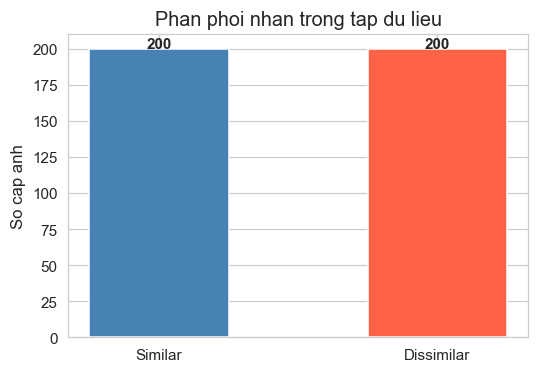

In [39]:
# ============================================================
# HIEN THI THONG KE DU LIEU
# ============================================================
print("="*50)
print("THONG KE TAP DU LIEU")
print("="*50)

total     = len(df_pairs)
n_similar = (df_pairs["label"] == 1).sum()
n_dissim  = (df_pairs["label"] == 0).sum()

print(f"Tong so cap anh hop le : {total}")
print(f"  Similar  (label=1)   : {n_similar:>5}  ({n_similar/total*100:.1f}%)")
print(f"  Dissimilar (label=0) : {n_dissim:>5}  ({n_dissim/total*100:.1f}%)")

# Bieu do phan phoi nhan
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(["Similar", "Dissimilar"], [n_similar, n_dissim],
       color=["steelblue", "tomato"], edgecolor="white", width=0.5)
ax.set_title("Phan phoi nhan trong tap du lieu")
ax.set_ylabel("So cap anh")
for i, v in enumerate([n_similar, n_dissim]):
    ax.text(i, v + 0.5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

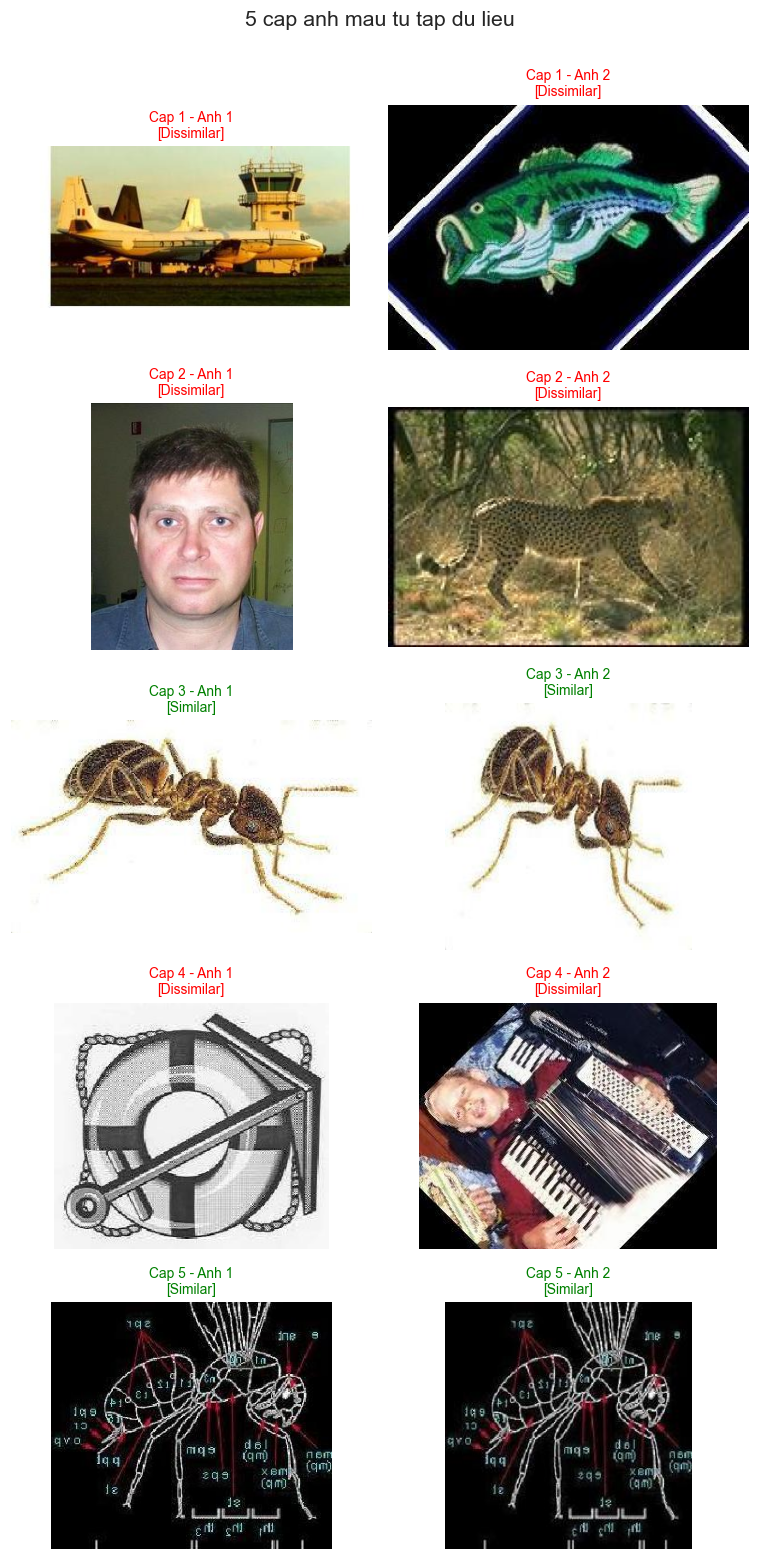

In [40]:
# ============================================================
# HIEN THI NGAU NHIEN 5 CAP ANH MAU
# ============================================================
def show_sample_pairs(df: pd.DataFrame, n: int = 5, seed: int = RANDOM_SEED):
    """
    Hien thi n cap anh ngau nhien tu DataFrame.
    Moi cap gom: anh1 | anh2 | nhan (Similar/Dissimilar)
    """
    sample = df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)
    fig, axes = plt.subplots(n, 2, figsize=(7, n * 2.8))
    fig.suptitle(f"{n} cap anh mau tu tap du lieu", fontsize=14, y=1.01)

    for i, row in sample.iterrows():
        label_str = "Similar" if row["label"] == 1 else "Dissimilar"
        color     = "green"   if row["label"] == 1 else "red"

        for j, img_path in enumerate([row["img1"], row["img2"]]):
            ax = axes[i][j] if n > 1 else axes[j]
            try:
                img = Image.open(img_path).convert("RGB")
                ax.imshow(img)
            except Exception as e:
                ax.text(0.5, 0.5, f"Loi anh\n{e}",
                        ha="center", va="center", transform=ax.transAxes)
            ax.set_title(
                f"Cap {i+1} - Anh {'1' if j==0 else '2'}\n[{label_str}]",
                color=color, fontsize=9
            )
            ax.axis("off")

    plt.tight_layout()
    plt.show()


show_sample_pairs(df_pairs, n=SAMPLE_N)

## Phan 3: Xay Dung Thuat Toan Wavelet Hash

### Nguyen ly hoat dong

**Wavelet Hash (wHash)** la ky thuat bien doi anh thanh chuoi bit nhi phan dua tren Discrete Wavelet Transform:

1. **Resize** anh ve kich thuoc `(HASH_SIZE * 2) x (HASH_SIZE * 2)` de DWT co du mau
2. **Grayscale** de loai bo thong tin mau, chi giu cau truc hinh dang
3. **Ap dung DWT** mot cap: thu duoc 4 bang he so: `LL, LH, HL, HH`
4. **Lay bang LL** (Low-Low) chua thong tin tan so thap - tuong duong "phien ban thu nho" cua anh
5. **Luong tu hoa**: so sanh moi pixel voi gia tri trung binh -> ra bit 0 hoac 1
6. **Ket qua**: vector nhi phan dai `HASH_SIZE * HASH_SIZE` bit

Hai anh giong nhau se co hash tuong tu, khoang cach Hamming nho.

In [41]:
# ============================================================
# HAM WAVELET HASH CHINH
# ============================================================
def wavelet_hash(image_path: str,
                 hash_size: int = HASH_SIZE,
                 wavelet: str = DEFAULT_WAVELET) -> np.ndarray:
    """
    Tinh Wavelet Hash cho mot anh.

    Tham so:
        image_path : duong dan toi file anh
        hash_size  : kich thuoc cua hash (hash_size x hash_size bit)
        wavelet    : ten wavelet su dung (haar, db1, db2, ...)

    Tra ve:
        np.ndarray dtype=bool, shape=(hash_size*hash_size,)
        hoac None neu khong doc duoc anh
    """
    try:
        # Buoc 1: Mo va resize anh
        # Nhan 2 vi DWT cat doi kich thuoc, can du mau cho bang LL
        target_size = (hash_size * 2, hash_size * 2)
        img = Image.open(image_path)

        # Xu ly anh co kenh alpha (RGBA) hoac mode la
        if img.mode == "RGBA":
            bg = Image.new("RGB", img.size, (255, 255, 255))
            bg.paste(img, mask=img.split()[3])
            img = bg
        elif img.mode not in ("RGB", "L"):
            img = img.convert("RGB")

        # Buoc 2: Chuyen grayscale
        img = img.convert("L")

        # Resize ve kich thuoc chuan
        img = img.resize(target_size, Image.Resampling.LANCZOS)

        # Buoc 3: Chuyen sang numpy array float
        pixels = np.asarray(img, dtype=np.float32)

        # Buoc 4: Ap dung DWT 2D mot cap
        # pywt.dwt2 tra ve: (LL, (LH, HL, HH))
        coeffs = pywt.dwt2(pixels, wavelet)
        LL, (LH, HL, HH) = coeffs

        # Buoc 5: Kiem tra kich thuoc bang LL
        # Trong truong hop wavelet cho bang LL nho hon hash_size
        if LL.shape[0] < hash_size or LL.shape[1] < hash_size:
            LL_resized = np.array(
                Image.fromarray(LL.astype(np.float32)).resize((hash_size, hash_size),
                                           Image.Resampling.LANCZOS)
            )
        else:
            # Cat lay hash_size x hash_size tu goc trai tren
            LL_resized = LL[:hash_size, :hash_size]

        # Buoc 6: Luong tu hoa - so sanh voi gia tri trung binh
        mean_val = LL_resized.mean()
        hash_bits = (LL_resized > mean_val).flatten()  # bool array

        return hash_bits

    except (FileNotFoundError, UnidentifiedImageError, OSError) as e:
        print(f"  [LOI] Khong xu ly duoc anh: {image_path} | {e}")
        return None
    except Exception as e:
        print(f"  [LOI KHONG XAC DINH] {image_path} | {e}")
        return None


# ============================================================
# HAM TINH KHOANG CACH HAMMING
# ============================================================
def hamming_distance(hash1: np.ndarray, hash2: np.ndarray) -> int:
    """
    Tinh khoang cach Hamming giua 2 hash (so bit khac nhau).
    """
    return int(np.sum(hash1 != hash2))


# ============================================================
# HAM CHUAN HOA VE SIMILARITY SCORE [0, 1]
# ============================================================
def hamming_to_similarity(dist: int, hash_length: int) -> float:
    """
    Chuyen doi khoang cach Hamming thanh diem tuong dong [0, 1].
    dist=0  -> similarity=1.0 (hoan toan giong)
    dist=max -> similarity=0.0 (hoan toan khac)
    """
    return 1.0 - dist / hash_length


# ============================================================
# KIEM TRA NHANH
# ============================================================
print("Kiem tra nhanh ham wavelet_hash ...")
_test_path = df_pairs["img1"].iloc[0]
_h = wavelet_hash(_test_path)
if _h is not None:
    print(f"  Anh test    : {_test_path}")
    print(f"  Hash length : {len(_h)} bit")
    print(f"  Hash mau    : {_h[:16].astype(int)} ...")
    print("  Ket qua: OK")
else:
    print("  Ket qua: THAT BAI - kiem tra lai duong dan anh")

Kiem tra nhanh ham wavelet_hash ...
  Anh test    : ..\./data/DWT/images/Faces_easy_0.jpg
  Hash length : 64 bit
  Hash mau    : [1 1 1 1 0 1 1 1 1 1 0 0 0 0 0 1] ...
  Ket qua: OK


## Phan 4: So Sanh Anh - Tinh Hash & Khoang Cach

In [42]:
# ============================================================
# TINH HASH VA KHOANG CACH CHO TOAN BO TAP DU LIEU
# ============================================================
def compute_all_similarities(df: pd.DataFrame,
                              hash_size: int = HASH_SIZE,
                              wavelet: str = DEFAULT_WAVELET) -> pd.DataFrame:
    """
    Tinh hash va khoang cach Hamming cho tat ca cap anh trong df.
    Tra ve DataFrame gom them: hamming_dist, similarity, label
    """
    hash_length = hash_size * hash_size
    results = []

    for _, row in tqdm(df.iterrows(), total=len(df),
                       desc=f"[{wavelet}] Tinh hash", ncols=80):
        h1 = wavelet_hash(row["img1"], hash_size, wavelet)
        h2 = wavelet_hash(row["img2"], hash_size, wavelet)

        if h1 is None or h2 is None:
            # Bo qua cap loi
            continue

        dist = hamming_distance(h1, h2)
        sim  = hamming_to_similarity(dist, hash_length)

        results.append({
            "img1"        : row["img1"],
            "img2"        : row["img2"],
            "label"       : row["label"],
            "hamming_dist": dist,
            "similarity"  : sim
        })

    return pd.DataFrame(results)


# Chay voi wavelet mac dinh (haar)
print(f"Dang tinh similarity cho tap TRAIN voi wavelet = '{DEFAULT_WAVELET}' ...")
df_result_train = compute_all_similarities(df_train, HASH_SIZE, DEFAULT_WAVELET)

print(f"\nHoan thanh: {len(df_result_train)} cap anh trong tap TRAIN duoc xu ly.")
print("\nXem truoc ket qua tap TRAIN:")
df_result_train[["hamming_dist", "similarity", "label"]].describe().round(3)

Dang tinh similarity cho tap TRAIN voi wavelet = 'haar' ...


[haar] Tinh hash:   0%|                                 | 0/320 [00:00<?, ?it/s]

[haar] Tinh hash: 100%|██████████████████████| 320/320 [00:00<00:00, 544.37it/s]


Hoan thanh: 320 cap anh trong tap TRAIN duoc xu ly.

Xem truoc ket qua tap TRAIN:


,hamming_dist,similarity,label
count,320.000,320.000,320.000
mean,17.491,0.727,0.500
std,16.067,0.251,0.501
min,0.000,0.172,0.000
25%,0.000,0.500,0.000
50%,16.500,0.742,0.500
75%,32.000,1.000,1.000
max,53.000,1.000,1.000


In [43]:
# ============================================================
# THU NHIEU GIA TRI THRESHOLD
# ============================================================
# Threshold duoc ap dung tren similarity score:
#   predicted = 1 (similar)   neu similarity >= threshold
#   predicted = 0 (dissimilar) neu similarity < threshold

thresholds = np.arange(0.0, 1.01, 0.01)
y_true_train = df_result_train["label"].values
y_score_train = df_result_train["similarity"].values

threshold_results = []
for t in thresholds:
    y_pred = (y_score_train >= t).astype(int)
    acc  = accuracy_score(y_true_train, y_pred)
    prec = precision_score(y_true_train, y_pred, zero_division=0)
    rec  = recall_score(y_true_train, y_pred, zero_division=0)
    f1   = f1_score(y_true_train, y_pred, zero_division=0)
    threshold_results.append({
        "threshold" : round(t, 2),
        "accuracy"  : acc,
        "precision" : prec,
        "recall"    : rec,
        "f1"        : f1
    })

df_thresh = pd.DataFrame(threshold_results)

# Tim threshold tot nhat theo F1 tren tap TRAIN
best_idx   = df_thresh["f1"].idxmax()
best_row   = df_thresh.loc[best_idx]
BEST_THRESHOLD = best_row["threshold"]

print("Threshold tot nhat tim duoc tu tap TRAIN:")
print(best_row.to_string())

Threshold tot nhat tim duoc tu tap TRAIN:
threshold    0.710000
accuracy     0.978125
precision    0.969325
recall       0.987500
f1           0.978328


## Phan 5: Danh Gia Mo Hinh

Su dung threshold toi uu tu tap TRAIN de tinh toan day du cac chi so danh gia tren tap TEST.

In [44]:
# ============================================================
# TINH SIMILARITY CHO TAP TEST
# ============================================================
print(f"Dang tinh similarity cho tap TEST voi wavelet = '{DEFAULT_WAVELET}' ...")
df_result_test = compute_all_similarities(df_test, HASH_SIZE, DEFAULT_WAVELET)

print(f"\nHoan thanh: {len(df_result_test)} cap anh trong tap TEST duoc xu ly.")

Dang tinh similarity cho tap TEST voi wavelet = 'haar' ...


[haar] Tinh hash: 100%|████████████████████████| 80/80 [00:00<00:00, 534.62it/s]


Hoan thanh: 80 cap anh trong tap TEST duoc xu ly.


In [45]:
# ============================================================
# DANH GIA VOI THRESHOLD TOI UU
# ============================================================
y_true_test = df_result_test["label"].values
y_score_test = df_result_test["similarity"].values

y_pred_best = (y_score_test >= BEST_THRESHOLD).astype(int)

acc  = accuracy_score(y_true_test, y_pred_best)
prec = precision_score(y_true_test, y_pred_best, zero_division=0)
rec  = recall_score(y_true_test, y_pred_best, zero_division=0)
f1   = f1_score(y_true_test, y_pred_best, zero_division=0)
cm   = confusion_matrix(y_true_test, y_pred_best)
fpr, tpr, _ = roc_curve(y_true_test, y_score_test)
roc_auc = auc(fpr, tpr)

print("="*50)
print(f"KET QUA DANH GIA TREN TAP TEST (wavelet={DEFAULT_WAVELET}, threshold={BEST_THRESHOLD})")
print("="*50)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-score  : {f1:.4f}")
print(f"  AUC       : {roc_auc:.4f}")
print()
print("Confusion Matrix:")
print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
print(f"  FN={cm[1,0]}  TP={cm[1,1]}")

KET QUA DANH GIA TREN TAP TEST (wavelet=haar, threshold=0.71)
  Accuracy  : 0.9750
  Precision : 0.9524
  Recall    : 1.0000
  F1-score  : 0.9756
  AUC       : 0.9988

Confusion Matrix:
  TN=38  FP=2
  FN=0  TP=40


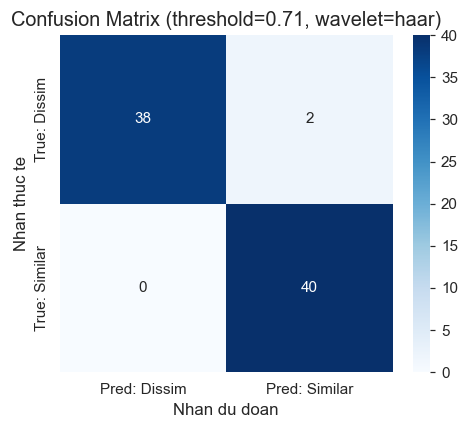

In [46]:
# ============================================================
# VE CONFUSION MATRIX
# ============================================================
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: Dissim", "Pred: Similar"],
    yticklabels=["True: Dissim", "True: Similar"],
    ax=ax
)
ax.set_title(f"Confusion Matrix (threshold={BEST_THRESHOLD}, wavelet={DEFAULT_WAVELET})")
ax.set_ylabel("Nhan thuc te")
ax.set_xlabel("Nhan du doan")
plt.tight_layout()
plt.show()

## Phan 6: Visualization

Bieu do truc quan hoa ket qua phan tich.

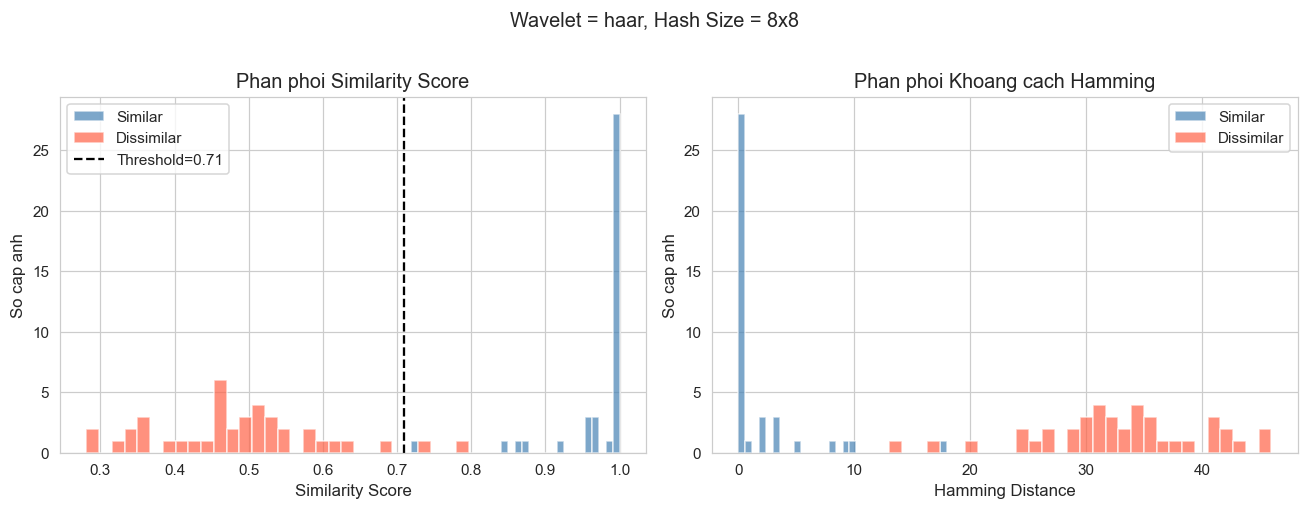

In [47]:
# ============================================================
# BIEU DO 1: HISTOGRAM KHOANG CACH SIMILAR VS DISSIMILAR
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sim_vals   = df_result_test.loc[df_result_test["label"]==1, "similarity"]
dissim_vals= df_result_test.loc[df_result_test["label"]==0, "similarity"]
ham_sim    = df_result_test.loc[df_result_test["label"]==1, "hamming_dist"]
ham_dissim = df_result_test.loc[df_result_test["label"]==0, "hamming_dist"]

# Subplot 1: Similarity score
ax = axes[0]
ax.hist(sim_vals,   bins=30, alpha=0.7, color="steelblue", label="Similar", edgecolor="white")
ax.hist(dissim_vals,bins=30, alpha=0.7, color="tomato",    label="Dissimilar", edgecolor="white")
ax.axvline(BEST_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
           label=f"Threshold={BEST_THRESHOLD}")
ax.set_title("Phan phoi Similarity Score")
ax.set_xlabel("Similarity Score")
ax.set_ylabel("So cap anh")
ax.legend()

# Subplot 2: Hamming distance
ax = axes[1]
ax.hist(ham_sim,   bins=30, alpha=0.7, color="steelblue", label="Similar", edgecolor="white")
ax.hist(ham_dissim,bins=30, alpha=0.7, color="tomato",    label="Dissimilar", edgecolor="white")
ax.set_title("Phan phoi Khoang cach Hamming")
ax.set_xlabel("Hamming Distance")
ax.set_ylabel("So cap anh")
ax.legend()

plt.suptitle(f"Wavelet = {DEFAULT_WAVELET}, Hash Size = {HASH_SIZE}x{HASH_SIZE}",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

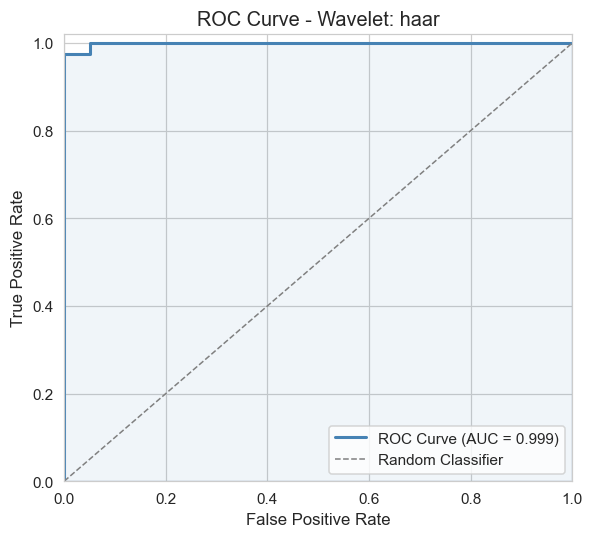

In [48]:
# ============================================================
# BIEU DO 2: ROC CURVE
# ============================================================
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"ROC Curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1, label="Random Classifier")
ax.fill_between(fpr, tpr, alpha=0.08, color="steelblue")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve - Wavelet: {DEFAULT_WAVELET}")
ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

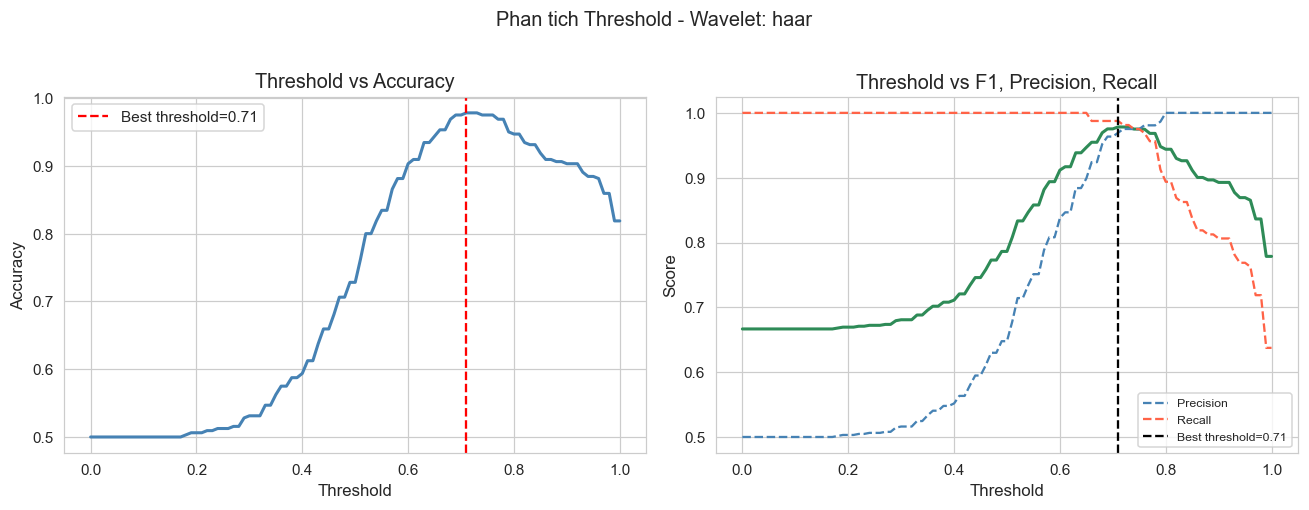

In [49]:
# ============================================================
# BIEU DO 3: THRESHOLD VS ACCURACY & F1
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Subplot 1: Accuracy theo threshold
ax = axes[0]
ax.plot(df_thresh["threshold"], df_thresh["accuracy"],
        color="steelblue", lw=2)
ax.axvline(BEST_THRESHOLD, color="red", linestyle="--", lw=1.5,
           label=f"Best threshold={BEST_THRESHOLD}")
ax.set_title("Threshold vs Accuracy")
ax.set_xlabel("Threshold")
ax.set_ylabel("Accuracy")
ax.legend()

# Subplot 2: F1 theo threshold
ax = axes[1]
ax.plot(df_thresh["threshold"], df_thresh["f1"],
        color="seagreen", lw=2)
ax.plot(df_thresh["threshold"], df_thresh["precision"],
        color="steelblue", lw=1.5, linestyle="--", label="Precision")
ax.plot(df_thresh["threshold"], df_thresh["recall"],
        color="tomato",   lw=1.5, linestyle="--", label="Recall")
ax.axvline(BEST_THRESHOLD, color="black", linestyle="--", lw=1.5,
           label=f"Best threshold={BEST_THRESHOLD}")
ax.set_title("Threshold vs F1, Precision, Recall")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.legend(fontsize=8)

plt.suptitle(f"Phan tich Threshold - Wavelet: {DEFAULT_WAVELET}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Phan 7: Bai Nang Cao - So Sanh Cac Loai Wavelet

Thu nghiem voi 5 wavelet khac nhau: `haar`, `db1`, `db2`, `db4`, `sym2` va so sanh ket qua.

In [50]:
# ============================================================
# HAM DANH GIA MOT WAVELET CHUAN (KHONG OVERFITTING)
# ============================================================
def evaluate_wavelet(df_train: pd.DataFrame,
                     df_test: pd.DataFrame,
                     wavelet: str,
                     hash_size: int = HASH_SIZE) -> dict:
    """
    Tinh toan chi so danh gia cho mot loai wavelet.
    Tim threshold toi uu tren tap TRAIN va danh gia tren tap TEST.
    """
    df_r_train = compute_all_similarities(df_train, hash_size, wavelet)
    df_r_test = compute_all_similarities(df_test, hash_size, wavelet)
    
    if len(df_r_train) == 0 or len(df_r_test) == 0:
        return None

    y_true_train  = df_r_train["label"].values
    y_score_train = df_r_train["similarity"].values
    y_true_test  = df_r_test["label"].values
    y_score_test = df_r_test["similarity"].values

    # 1. Tim threshold tot nhat tren tap TRAIN
    best_f1_train, best_t = 0, 0.5
    for t in np.arange(0.0, 1.01, 0.01):
        yp_train  = (y_score_train >= t).astype(int)
        f1v = f1_score(y_true_train, yp_train, zero_division=0)
        if f1v > best_f1_train:
            best_f1_train = f1v
            best_t = round(t, 2)

    # 2. Danh gia tren tap TEST bang best_t
    yp_test = (y_score_test >= best_t).astype(int)
    test_acc  = accuracy_score(y_true_test, yp_test)
    test_prec = precision_score(y_true_test, yp_test, zero_division=0)
    test_rec  = recall_score(y_true_test, yp_test, zero_division=0)
    test_f1   = f1_score(y_true_test, yp_test, zero_division=0)

    # Tinh AUC tren tap TEST
    fpr, tpr, _ = roc_curve(y_true_test, y_score_test)
    auc_score   = auc(fpr, tpr)

    return {
        "wavelet"          : wavelet,
        "best_threshold"   : best_t,
        "accuracy"         : round(test_acc,  4),
        "precision"        : round(test_prec, 4),
        "recall"           : round(test_rec,  4),
        "f1_score"         : round(test_f1,   4),
        "auc"              : round(auc_score,  4),
        "n_processed"      : len(df_r_test),
        "_df_result"       : df_r_test,   
        "_fpr"             : fpr,
        "_tpr"             : tpr
    }


# ============================================================
# CHAY TREN 5 WAVELET (Danh gia khach quan tren tap TEST)
# ============================================================
WAVELETS_TO_TEST = ["haar", "db1", "db2", "db4", "sym2"]

wavelet_eval_results = []
for wname in WAVELETS_TO_TEST:
    print(f"\nDang danh gia wavelet: {wname} ...")
    res = evaluate_wavelet(df_train, df_test, wname, HASH_SIZE)
    if res:
        wavelet_eval_results.append(res)
        print(f"  F1={res['f1_score']:.4f}  AUC={res['auc']:.4f}  Acc={res['accuracy']:.4f}  Threshold={res['best_threshold']}")


Dang danh gia wavelet: haar ...


[haar] Tinh hash: 100%|████████████████████████| 80/80 [00:00<00:00, 542.65it/s]


  F1=0.9756  AUC=0.9988  Acc=0.9750  Threshold=0.71

Dang danh gia wavelet: db1 ...


[db1] Tinh hash: 100%|█████████████████████████| 80/80 [00:00<00:00, 514.38it/s]


  F1=0.9756  AUC=0.9988  Acc=0.9750  Threshold=0.71

Dang danh gia wavelet: db2 ...


...

  F1=0.9512  AUC=0.9969  Acc=0.9500  Threshold=0.72

Dang danh gia wavelet: db4 ...


[db4] Tinh hash: 100%|█████████████████████████| 80/80 [00:00<00:00, 540.96it/s]


  F1=0.9877  AUC=0.9972  Acc=0.9875  Threshold=0.74

Dang danh gia wavelet: sym2 ...


[sym2] Tinh hash: 100%|████████████████████████| 80/80 [00:00<00:00, 538.54it/s]


  F1=0.9512  AUC=0.9969  Acc=0.9500  Threshold=0.72


In [51]:
# ============================================================
# BANG SO SANH CAC WAVELET
# ============================================================
comparison_cols = ["wavelet", "best_threshold", "accuracy",
                   "precision", "recall", "f1_score", "auc", "n_processed"]

df_compare = pd.DataFrame([
    {k: r[k] for k in comparison_cols}
    for r in wavelet_eval_results
]).sort_values("f1_score", ascending=False).reset_index(drop=True)

print("="*70)
print("BANG SO SANH CAC LOAI WAVELET")
print("="*70)
print(df_compare.to_string(index=False))

best_wavelet_row = df_compare.iloc[0]
print(f"\nWavelet tot nhat: {best_wavelet_row['wavelet']} "
      f"(F1={best_wavelet_row['f1_score']}, AUC={best_wavelet_row['auc']})")

BANG SO SANH CAC LOAI WAVELET
wavelet  best_threshold  accuracy  precision  recall  f1_score    auc  n_processed
    db4            0.74    0.9875     0.9756   1.000    0.9877 0.9972           80
   haar            0.71    0.9750     0.9524   1.000    0.9756 0.9988           80
    db1            0.71    0.9750     0.9524   1.000    0.9756 0.9988           80
    db2            0.72    0.9500     0.9286   0.975    0.9512 0.9969           80
   sym2            0.72    0.9500     0.9286   0.975    0.9512 0.9969           80

Wavelet tot nhat: db4 (F1=0.9877, AUC=0.9972)


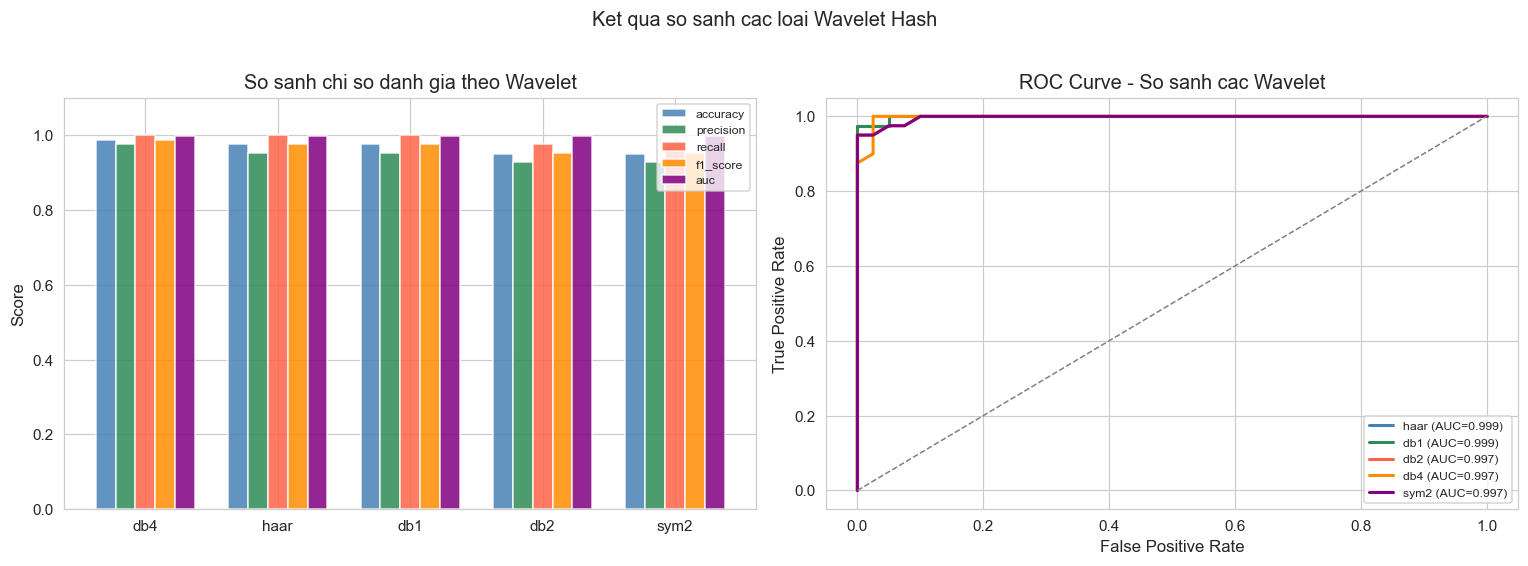

In [52]:
# ============================================================
# BIEU DO: SO SANH CAC WAVELET
# ============================================================
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score", "auc"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Grouped bar chart cac chi so
ax = axes[0]
x  = np.arange(len(df_compare))
width = 0.15
colors_bar = ["steelblue", "seagreen", "tomato", "darkorange", "purple"]

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, df_compare[metric], width,
           label=metric, color=colors_bar[i], alpha=0.85, edgecolor="white")

ax.set_xticks(x + width * 2)
ax.set_xticklabels(df_compare["wavelet"])
ax.set_ylabel("Score")
ax.set_ylim([0, 1.1])
ax.set_title("So sanh chi so danh gia theo Wavelet")
ax.legend(fontsize=8)

# Subplot 2: ROC Curve cua tat ca wavelet
ax = axes[1]
colors_roc = ["steelblue", "seagreen", "tomato", "darkorange", "purple"]
for i, res in enumerate(wavelet_eval_results):
    ax.plot(res["_fpr"], res["_tpr"],
            lw=2, color=colors_roc[i % len(colors_roc)],
            label=f"{res['wavelet']} (AUC={res['auc']:.3f})")

ax.plot([0, 1], [0, 1], "--", color="grey", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - So sanh cac Wavelet")
ax.legend(fontsize=8)

plt.suptitle("Ket qua so sanh cac loai Wavelet Hash", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

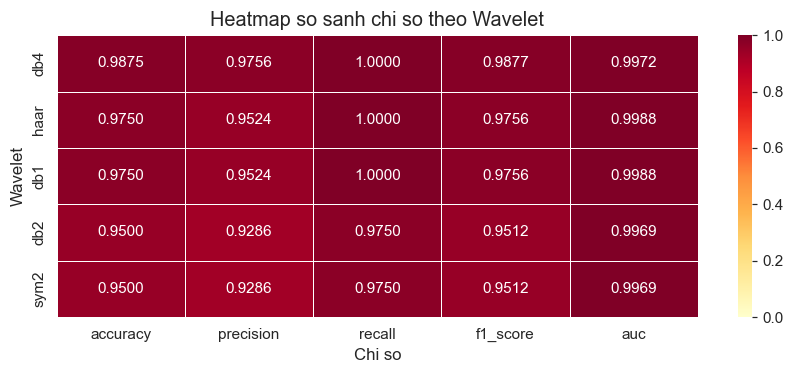

In [53]:
# ============================================================
# BIEU DO NANG CAO: HEATMAP BANG SO SANH
# ============================================================
df_heatmap = df_compare.set_index("wavelet")[["accuracy", "precision", "recall", "f1_score", "auc"]]

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(
    df_heatmap,
    annot=True, fmt=".4f", cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Heatmap so sanh chi so theo Wavelet")
ax.set_xlabel("Chi so")
ax.set_ylabel("Wavelet")
plt.tight_layout()
plt.show()

## Phan 8: Ket Luan

Tong hop ket qua va dua ra nhan xet cuoi bai.

In [54]:
# ============================================================
# KET LUAN TU DONG TU KET QUA
# ============================================================
best_wav = df_compare.iloc[0]
worst_wav = df_compare.iloc[-1]

print("="*65)
print("KET LUAN BAI THUC HANH SO 4")
print("So sanh anh bang Wavelet Hash (DWT)")
print("="*65)

print(f"""
1. WAVELET TOT NHAT: {best_wav['wavelet']}
   - F1-score  : {best_wav['f1_score']}
   - AUC       : {best_wav['auc']}
   - Accuracy  : {best_wav['accuracy']}
   - Threshold : {best_wav['best_threshold']}

2. WAVELET YEU NHAT: {worst_wav['wavelet']}
   - F1-score  : {worst_wav['f1_score']}
   - AUC       : {worst_wav['auc']}

3. BANG TOM TAT:
""")
print(df_compare[["wavelet", "best_threshold", "f1_score", "auc"]].to_string(index=False))

print("""
4. UU DIEM CUA WAVELET HASH:
   - Nhanh, nhe, khong can model hoc may
   - Khang nhieu tot voi bien doi nho (resize, compress nhe)
   - De cai dat, chi can pywt va PIL
   - Threshold co the chinh tay theo nhu cau

5. NHUOC DIEM:
   - Khong hieu qua voi bien doi manh (xoay, cat, them watermark)
   - Hash size anh huong den do chinh xac vs toc do
   - Khong hoc duoc dac trung semantic (ngu nghia) cua anh
   - Kem hieu qua hon deep learning (CNN, ViT, ...) voi tap lon

6. HUONG MO RONG:
   - Tang hash_size (16, 32) de giam collision
   - Ket hop nhieu level DWT (multi-level wavelet)
   - Dung pHash hoac aHash ket hop
   - Thu nghiem Siamese Network cho ket qua tot hon
""")

KET LUAN BAI THUC HANH SO 4
So sanh anh bang Wavelet Hash (DWT)

1. WAVELET TOT NHAT: db4
   - F1-score  : 0.9877
   - AUC       : 0.9972
   - Accuracy  : 0.9875
   - Threshold : 0.74

2. WAVELET YEU NHAT: sym2
   - F1-score  : 0.9512
   - AUC       : 0.9969

3. BANG TOM TAT:

wavelet  best_threshold  f1_score    auc
    db4            0.74    0.9877 0.9972
   haar            0.71    0.9756 0.9988
    db1            0.71    0.9756 0.9988
    db2            0.72    0.9512 0.9969
   sym2            0.72    0.9512 0.9969

4. UU DIEM CUA WAVELET HASH:
   - Nhanh, nhe, khong can model hoc may
   - Khang nhieu tot voi bien doi nho (resize, compress nhe)
   - De cai dat, chi can pywt va PIL
   - Threshold co the chinh tay theo nhu cau

5. NHUOC DIEM:
   - Khong hieu qua voi bien doi manh (xoay, cat, them watermark)
   - Hash size anh huong den do chinh xac vs toc do
   - Khong hoc duoc dac trung semantic (ngu nghia) cua anh
   - Kem hieu qua hon deep learning (CNN, ViT, ...) voi tap lon

6. H